In [1]:
using Pkg
Pkg.activate(normpath(@__DIR__,  ".."))

  Activating project at `~/DART`


In [2]:
include(normpath(joinpath(@__DIR__, "..", "utils", "utils.jl")))
using PyPlot, JLD2

include("../dl_train/test_model_keff.jl");

┌ Error: JULIA_CUDA_USE_BINARYBUILDER is deprecated. Call `CUDA.jl.set_runtime_version!` to use a local toolkit.
└ @ CUDA ~/.julia/packages/CUDA/x8d2s/src/initialization.jl:191


In [3]:
function load_jld2(path)
    @load path rn_met_dl
    return copy(rn_met_dl)
end

base = "../synthetic_data/ideal_data_rates/"

gen_b,   gen_nb1,  gen_nb0  = load_jld2.(base .* ["mgen_dlb33_compare_seed_2.jld2",
                                                    "mgen_dlnb133_compare_seed_17.jld2",
                                                    "mgen_dlnb033_compare_seed_35.jld2"])

tel_b,   tel_nb1,  tel_nb0  = load_jld2.(base .* ["mtel_dlb33_compare_seed_2.jld2",
                                                    "mtel_dlnb133_compare_seed_17.jld2",
                                                    "mtel_dlnb033_compare_seed_35.jld2"]);

#### plot

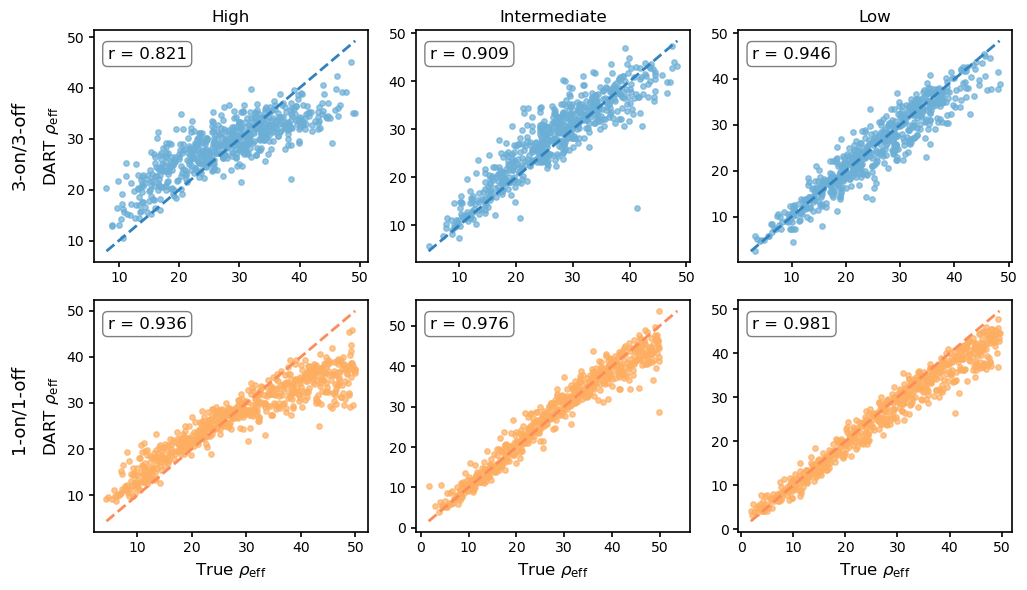

In [16]:
fig, axes = subplots(2, 3, figsize=(10, 6))
fs1 = 12
fs2 = 10

# --- Row 1 ---
for (ax, (label, metrics, title)) in zip(axes[1, :], [("b", gen_b, "High"), ("nb1", gen_nb1, "Intermediate"), ("nb0", gen_nb0, "Low")])
    true_r = [m.true_r for m in metrics]
    pred_r = [m.pred_r for m in metrics]
    ax.scatter(true_r, pred_r, alpha=0.7, s=15, c="#6baed6")
    sca(ax)
    fit_line(true_r, pred_r)
    lims = [min(minimum(true_r), minimum(pred_r)), max(maximum(true_r), maximum(pred_r))]
    ax.plot(lims, lims, "--", label="y=x", c="#3182bd",lw=2)
    ax.set_title(title)
    r_val = round(cor(true_r, pred_r), digits=3)
    ax.text(0.05, 0.93, "r = $r_val", fontsize=fs1, transform=ax.transAxes, verticalalignment="top",
            bbox=Dict("boxstyle"=>"round", "facecolor"=>"white", "alpha"=>0.5))
    wd = 1.2
    ax.tick_params(axis="both", labelsize=fs2, width=wd)
    for spine in ax.spines.values()
        spine.set_linewidth(wd)
    end
end
axes[1, 1].set_ylabel(L"DART $\rho_{\mathrm{eff}}$", fontsize=fs1)

# --- Row 2 ---
for (ax, (label, metrics, title)) in zip(axes[2, :], [("b", tel_b, "High"), ("nb1", tel_nb1, "Intermediate"), ("nb0", tel_nb0, "Low")])
    true_r = [m.true_r for m in metrics]
    pred_r = [m.pred_r for m in metrics]
    ax.scatter(true_r, pred_r, alpha=0.7, s=15, c="#fdae61")
    sca(ax)
    fit_line(true_r, pred_r)
    lims = [min(minimum(true_r), minimum(pred_r)), max(maximum(true_r), maximum(pred_r))]
    ax.plot(lims, lims, "--", label="y=x", c="#fc8d59",lw=2)
    ax.set_xlabel(L"True $\rho_{\mathrm{eff}}$", fontsize=fs1)
    r_val = round(cor(true_r, pred_r), digits=3)
    ax.text(0.05, 0.93, "r = $r_val", fontsize=fs1, transform=ax.transAxes, verticalalignment="top",
            bbox=Dict("boxstyle"=>"round", "facecolor"=>"white", "alpha"=>0.5))
    wd = 1.2
    ax.tick_params(axis="both", labelsize=fs2, width=wd)
    for spine in ax.spines.values()
        spine.set_linewidth(wd)
    end
end
axes[2, 1].set_ylabel(L"DART $\rho_{\mathrm{eff}}$", fontsize=fs1)

fig.text(-0.008, 0.75, "3-on/3-off", fontsize=fs1+1, rotation=90,
         verticalalignment="center", horizontalalignment="center")
fig.text(-0.008, 0.31, "1-on/1-off", fontsize=fs1+1, rotation=90,
         verticalalignment="center", horizontalalignment="center")

tight_layout()
fig.savefig("figs/gen_tel_rates.pdf", bbox_inches="tight", dpi=800);

#### posterior

In [5]:
data_dir = "../synthetic_data_multi/ideal_res_rates";

In [6]:
function collect_val(model_name::AbstractString; seeds::AbstractRange=1:50, data_dir::AbstractString=data_dir)
    mrels = Vector{Float64}()
    for s in seeds
        file = joinpath(data_dir, "mgen_dl$(model_name)_compare_seed_$(s).jld2")
        @load file rn_met_dl
        mrel = mean([m.rel_r for m in rn_met_dl])
        push!(mrels, mrel)
    end
    return mrels
end;

In [7]:
preds_b = collect_val("b33");
preds_nb1 = collect_val("nb133");
preds_nb0 = collect_val("nb033");

In [9]:
quantile_idx(preds_b,0.5),quantile_idx(preds_nb1,0.5),quantile_idx(preds_nb0,0.5)

([2], [17], [35])